# Article Recommendation System
### Data Science & Machine Learning


**Business Problem:** How can Star Media Group leverage reader demographics, historical
article interactions and article metadata to better understand reader behaviour and
develop an intelligent solution that improves content personalisation, user engagement,
and ultimately business conversion?

**Objective:** Use reader demographics, historical article interactions, and article metadata to improve content personalisation, engagement, and potential conversion.

This analysis methodology include: **Business Problem → Data Understanding → Data Preparation →
Insights → Modeling → Evaluation → Business Recommendation**.

## Business Understanding & Problem Definition

### Prioritised use case:
**Personalised article recommendation system**.

**Justification:**
- It directly uses all three available datasets.
- It can be integrated into the homepage, article page or "Recommended for you" module.
- It has a clear business KPI: CTR/article views, with downstream KPIs such as retention and subscription conversion.

### Additional useful data but is currently missing

- Depth-of-engagement signals: dwell time, scroll depth, shares, comments, bookmarks.
- Reader feedback: likes, follows, subscribe or saves.

### Assumptions
- `is_viewed = 1` is treated as positive implicit feedback.
- The article join is `user_article_history.article_id = article_list.content_id`.
- Demographics are supporting signals, not the main driver of recommendations.
- Recommendations should only contain articles that were published by the recommendation time.
- Because many non-viewed records have missing timestamps, time-based evaluation is performed primarily on timestamped viewed events.

## Part B — Data Understanding & Data Quality Assessment

The assessment defines:
- `user_demographics.csv`: one row per reader, primary key `cxuserid`.
- `user_article_history.csv`: user/article interaction records, with `is_viewed` where 1 = viewed and 0 = not viewed.
- `article_list.csv`: article metadata, primary key `content_id`.
- Join: `user_article_history.article_id = article_list.content_id`.

These relationships are important because a recommendation system needs to combine **who the reader is**, **what they interacted with**, and **what each article is about**.

#### Load the datasets

In [15]:
import pandas as pd
import numpy as np

# Load datasets
users = pd.read_csv("data/user_demographics.csv")
history = pd.read_csv("data/user_article_history.csv")
article = pd.read_csv("data/article_list.csv")

print("Users:", users.shape)
print("History:", history.shape)
print("Articles:", article.shape)


Users: (305, 6)
History: (14475, 4)
Articles: (8043, 5)


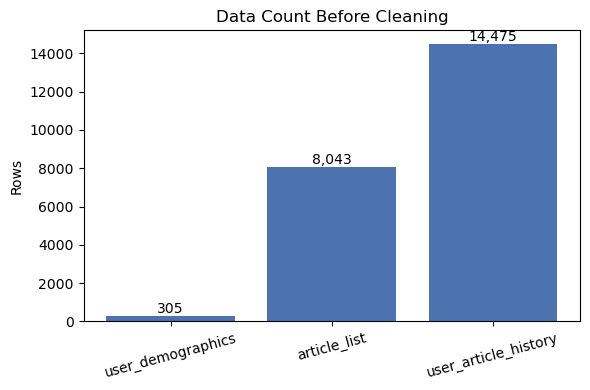

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
datasets = ['user_demographics', 'article_list', 'user_article_history']
sizes = [len(users), len(article), len(history)]
bars = ax.bar(datasets, sizes, color='#4C72B0')
ax.set_ylabel('Rows')
ax.set_title('Data Count Before Cleaning')
for b, v in zip(bars, sizes):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [17]:
print("-- User Demographics --") 
print(users.dtypes)
print("\n-- User Article History --")
print(history.dtypes)
print("\n-- Article List --")
print(article.dtypes)

-- User Demographics --
cxuserid           object
gender             object
race               object
city               object
education_level    object
occupation         object
dtype: object

-- User Article History --
cxuserid            object
record_datetime     object
article_id         float64
is_viewed            int64
dtype: object

-- Article List --
content_id                   int64
content_title               object
content_category            object
content_publish_datetime    object
content_sentiment           object
dtype: object


**Data types**

Based on above, we can see that `article_id` loads as `float64` not string because of 8 null rows and both datetime
columns load as `object`. The variables need explicit conversion before they're usable.

### Missing Value

In [18]:
def quality_report(df, name):
    return pd.DataFrame({
        "dataset": name,
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "missing_cells": [int(df.isna().sum().sum())]
    })

display(pd.concat([
    quality_report(users, "User Demographics"),
    quality_report(history, "User Article History"),
    quality_report(article, "Article List")
], ignore_index=True))


,dataset,rows,columns,missing_cells
0,User Demographics,305,6,0
1,User Article History,14475,4,8
2,Article List,8043,5,552


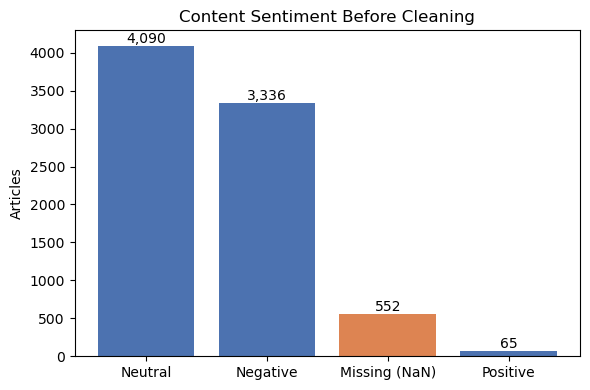

In [24]:
#Visualization for Sentiment Category (Article List Dataset)

fig, ax = plt.subplots(figsize=(6, 4))
sent_before = article['content_sentiment'].value_counts(dropna=False)
sent_before.index = sent_before.index.fillna('Missing (NaN)')
colors = ['#DD8452' if lab == 'Missing (NaN)' else '#4C72B0' for lab in sent_before.index]
bars = ax.bar(sent_before.index.astype(str), sent_before.values, color=colors)
ax.set_ylabel('Articles')
ax.set_title('Content Sentiment Before Cleaning')
for b, v in zip(bars, sent_before.values):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Duplicate Value

In [25]:
def duplicate_report(df, name):
    return pd.DataFrame({
        "dataset": [name],
        "duplicate_rows": [df.duplicated().sum()]
    })

display(pd.concat([
    duplicate_report(users, "User Demographics"),
    duplicate_report(history, "User Article History"),
    duplicate_report(article, "Article List")
], ignore_index=True))

,dataset,duplicate_rows
0,User Demographics,0
1,User Article History,0
2,Article List,0


**Finding Missing & Duplicate Value:**
- `user_demographics`: 305 readers, one row each, no missing values, no
  duplicate ids. Clean.
- `user_article_history`: 14,475 rows. `article_id` is missing on 8 rows
  (0.06%). Those rows contain missing value can't be linked to any article and can't be used.
- `article_list`: 8,043 articles. `content_sentiment` is missing on 552
  articles (6.863%). These articles maybe were never sentiment-tagged
  (e.g. older or auto-published content), not something can be should assume
  is random.

In [26]:
# Finding: are the is_viewed=0 ("not clicked") rows


hist_tmp = history.copy()
hist_tmp["record_datetime"] = hist_tmp["record_datetime"].apply(pd.to_datetime)
print(hist_tmp.groupby("is_viewed")["record_datetime"].agg(["min", "max", "count"]))


                                 min                        max  count
is_viewed                                                             
0         2025-07-15 13:30:00.000000 2025-12-15 13:30:00.000000   5426
1         2025-01-14 13:41:38.569773 2026-08-21 10:00:51.204700   9049


**Finding for is_viewed:**

- `is_viewed = 0` (shown but not clicked) is recorded only between 15 July 2025 and 15 December 2025. Outside this ~5-month period, every interaction is is_viewed = 1. This indicates that "not clicked" events were only logged during this window period while data before and after it captures clicks only, with no record of what was shown but ignored.

- Why this matters: A click-prediction model requires genuine examples of both outcomes (clicked and not clicked) for the same period. Using the full dataset as-is would mislead the model: periods outside the labelled window would appear to have a 100% click rate, not because readers clicked everything, but because misses were never recorded there.

- Decision: Model training and evaluation are restricted to the 15 July – 15 December 2025 window, where both outcomes are reliably observed. Data outside this window remains in the dataset for exploratory analysis and reader segmentation but is excluded from modelling to avoid this bias.

### Format `record_datetime` 

In [27]:
# Convert dates format: record_datetime is stored in two formats (with and without microseconds)
# in the same column, so a naive parse silently produces missing dates for one of the two formats. 
# We parse each value one at a time (.apply(pd.to_datetime)) so every row gets its own correctly-guessed



history["record_datetime"] = history["record_datetime"].apply(pd.to_datetime)
article["content_publish_datetime"] = article["content_publish_datetime"].apply(pd.to_datetime)

print("Interaction date range:", history["record_datetime"].min(), "to", history["record_datetime"].max())
print("Article publish date range:", article["content_publish_datetime"].min(), "to", article["content_publish_datetime"].max())
print("Unparseable Interaction dates after fix:", history["record_datetime"].isnull().sum())

Interaction date range: 2025-01-14 13:41:38.569773 to 2026-08-21 10:00:51.204700
Article publish date range: 2020-01-02 07:00:00 to 2026-08-21 09:19:00
Unparseable Interaction dates after fix: 0


### Join Data

**Join plan:** `user_article_history` is the centre table (one row per
impression). We attach reader info with a left join on `cxuserid`, and
article info with a left join on `article_id = content_id`. We use left
joins (not inner) so we can *measure* how much data would be lost by a
stricter join, rather than silently losing rows.

In [28]:
print("=== Join risk checking ===")
print("readers in history but missing from demographics:", (~history["cxuserid"].isin(users["cxuserid"])).sum())

hist_valid_ids = history.dropna(subset=["article_id"]).copy()
hist_valid_ids["article_id_str"] = hist_valid_ids["article_id"].astype(int).astype(str)
article["content_id_str"] = article["content_id"].astype(str)

orphan_mask = ~hist_valid_ids["article_id_str"].isin(set(article["content_id_str"]))
print(f"interaction rows whose article_id has no matching article: {orphan_mask.sum()} "
      f"({orphan_mask.mean()*100:.2f}% of rows with an article_id)")

=== Join risk checking ===
readers in history but missing from demographics: 0
interaction rows whose article_id has no matching article: 95 (0.66% of rows with an article_id)


In [29]:
display(hist_valid_ids[orphan_mask])

,cxuserid,record_datetime,article_id,is_viewed,article_id_str
66,b17717ab-7f6c-4fb6-ace7-32b13bc1d6fe,2026-05-06 21:10:32.224003,1868388.0,1,1868388
76,f6bb3565-5320-4f2b-91cb-3f9b811794af,2026-05-27 09:52:56.318074,1882400.0,1,1882400
612,b8524e69-53a6-4b9a-98cc-17251106bbe6,2026-05-07 07:56:38.849003,1864922.0,1,1864922
662,87a40d81-85f4-49f4-a8ef-3704568fbcd8,2026-08-18 17:00:23.606482,1939137.0,1,1939137
880,be0ec92f-62f6-4ea1-9a6d-57db693e7625,2026-05-27 16:53:50.176377,1882631.0,1,1882631
...,...,...,...,...,...
14416,3dc5c511-e7cb-45ef-ad63-3594e8e91437,2026-05-28 16:44:08.108903,1882702.0,1,1882702
14417,3dc5c511-e7cb-45ef-ad63-3594e8e91437,2026-05-28 19:50:00.485528,1883053.0,1,1883053
14418,3dc5c511-e7cb-45ef-ad63-3594e8e91437,2026-06-07 13:09:02.649649,1882702.0,1,1882702
14428,1ad66805-4091-4585-ae22-150a0f431337,2026-05-18 14:19:28.323008,1876195.0,1,1876195


In [30]:
# Validate the join: after joining

joined_check = hist_valid_ids.merge(users, on="cxuserid", how="left").merge(
    article, left_on="article_id_str", right_on="content_id_str", how="left"
)
print("rows before join:", len(hist_valid_ids), "| rows after join:", len(joined_check))
print("rows with no matching article after join:", joined_check["content_id"].isnull().sum())
print("rows with no matching reader after join:", joined_check["gender"].isnull().sum())

rows before join: 14467 | rows after join: 14467
rows with no matching article after join: 95
rows with no matching reader after join: 0


**Finding join data:**

- The missing 95 `article_id` indicate articles exist but likely were later removed/unpublished or a metadata export gap.
- These rows cannot get article features, so they'll be dropped before modelling.

## Part C — Data Cleaning & Preprocessing

## Data Cleaning Decisions

**1. Missing `article_id` (8 rows in `user_article_history`)**
- Issue: no article reference at all, so the row is unusable for anything
article-related. 
- Treatment: drop these 8 rows (0.06% of data — negligible loss). 
- Rationale: we can't invent an article id, and keeping them would
force us to fabricate values.

**2. No match `article_id`s (95 rows, 0.66%) in `article_list.csv`**
- Issue: There are no match found for 95 `article_id` with `article_list`'s `content_id` column. 
- Treatment: Drop before modelling 
- Rationale: without article metadata we cannot build article-level features for these rows and 0.66% is small enough that dropping doesn't cause bias the dataset.

**3. Missing `content_sentiment` (552 articles, 6.9%)**
- Issue: sentiment unknown. Treatment: **keep the rows**, fill with an explicit `"Unknown"` category rather than the mode. 
- Rationale: silently imputing "Neutral" would invent information we don't have and could bias a sentiment-based feature; treating "unknown" as its own category lets the model learn from it honestly (and 552 articles is too many to drop).

**4. Inconsistent category labels in `education_level` / `occupation`**
- Issue: e.g. `"DEGREE"`, `"BACHELOR'S DEGREE"` and `"HONOURS DEGREE"` are effectively overlapping categories from a survey with inconsistent options; `"MASTERS"` and `"MASTER'S DEGREE"` are the same thing typed two ways. 
- Treatment: map into a consistent naming and grouping. 
- Rationale: without this, a model would treat "DEGREE" and "BACHELOR'S DEGREE" as unrelated, which is both wrong and adds noise/sparsity.

**5. Repeated reader article interactions (1,842 pairs shown more than
once, 4,264 rows involved)**
- Issue: the same reader/article pair appears multiple times. Checked: the `is_viewed` outcome is *never* contradictory across repeats of the same pair (0 conflicts), so these are genuine repeat impressions, not a data error. 
- Treatment: for modelling, keep only the **first** impression per reader–article pair. 
- Rationale: keeping duplicates would let the same outcome appear in both the training and test period around the split boundary and over-weight repeatedly-shown articles; the first exposure is also the most realistic "was this a good recommendation" signal.

**6. Mixed datetime formats**
- already fixed in **Format `record_datetime`*

**7. Rare article categories** 
- Issue:  — Categories `ESG`: 3 articles, `Food`: 11 are too small to let a model learn a reliable pattern for them, and cause unstable percentages in charts. 
- Treatment: group any category with under 30 articles into `"Other"` for modelling/feature purposes, while keeping the original label in the raw data.

**Privacy & bias considerations (demographic data):**
`gender`, `race`, `city`, `education_level`, `occupation` are sensitive
attributes. Using them directly as recommendation-model inputs risks the
model learning to show different *types* of content to different
demographic groups in a way that could feel discriminatory or create
filter bubbles (e.g. never showing Business news to one gender because of
a historical pattern in the data). For this assessment we EDA them for
insight, but for the production-facing model we prefer **behavioural**
features (what a reader has actually read) over demographic features, and
if demographics are used at all, we'd audit the model's recommendations
across groups before shipping it. Reader ids are already anonymised
(`cxuserid`), which is good practice.

In [31]:
# --- Apply the cleaning decisions ---
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

# 1. Drop rows with no article_id
hist_clean = history.dropna(subset=["article_id"]).copy()
hist_clean["article_id"] = hist_clean["article_id"].astype(int).astype(str)
print("history rows after dropping missing article_id:", len(hist_clean))
print("\n")


# 3. Sentiment: explicit "Unknown" bucket
art_clean = article.copy()
art_clean["content_sentiment"] = art_clean["content_sentiment"].fillna("Unknown")


# 4. Standardise education_level.
def highest_education(raw):
    x = str(raw).upper()
    if "PHD" in x:
        return "PhD"
    if "MASTER" in x or "POST GRADUATE" in x:
        return "Master's / Postgrad"
    if "DEGREE" in x or "ADVANCED DIPLOMA" in x:  # bachelor's, honours, degree
        return "Bachelor's Degree"
    if "DIPLOMA" in x or "PRE - U" in x or "STPM" in x:
        return "Diploma / Pre-U"
    if "SECONDARY" in x or "SPM" in x:
        return "Secondary School"
    if "PROFESSIONAL CERTIFICATE" in x:
        return "Professional Certificate"
    return "Undisclosed"  # covers "PREFER NOT TO DISCLOSE"

demo_clean = users.copy()
demo_clean["education_level_clean"] = demo_clean["education_level"].apply(highest_education)

# Occupation: bucket the long tail into a handful of groups
def bucket_occupation(x):
    x = str(x).upper()
    if "PMEB" in x or "MANAGER" in x or "EXECUTIVE" in x:
        return "PMEB / Management"
    if "UNEMPLOYED" in x or "RETIRED" in x:
        return "Unemployed / Retired"
    if "HOUSEWIFE" in x or "HUSBAND" in x:
        return "Homemaker"
    if "BLUE COLLAR" in x:
        return "Blue Collar"
    if "NO ANSWER" in x or "PREFER NOT" in x:
        return "Undisclosed"
    if "WHITE COLLAR" in x:
        return "Other White Collar"
    return "Other"

demo_clean["occupation_group"] = demo_clean["occupation"].apply(bucket_occupation)

# 7. Rare-category bucketing for articles
cat_counts = art_clean["content_category"].value_counts()
rare_cats = cat_counts[cat_counts < 30].index
art_clean["content_category_grouped"] = art_clean["content_category"].where(
    ~art_clean["content_category"].isin(rare_cats), "Other")

print(demo_clean[["education_level", "education_level_clean"]].drop_duplicates().sort_values("education_level"))
print()
print(demo_clean["occupation_group"].value_counts())
print()
print(art_clean["content_category_grouped"].value_counts())

history rows after dropping missing article_id: 14467


                                      education_level     education_level_clean
96                                   ADVANCED DIPLOMA         Bachelor's Degree
75                   ADVANCED DIPLOMA/DIPLOMA/MASTERS       Master's / Postgrad
174                   ADVANCED DIPLOMA/HONOURS DEGREE         Bachelor's Degree
2                                   BACHELOR'S DEGREE         Bachelor's Degree
7                                              DEGREE         Bachelor's Degree
176                                    DEGREE/DIPLOMA         Bachelor's Degree
14                                     DEGREE/MASTERS       Master's / Postgrad
19                    DEGREE/PRE - U/SECONDARY SCHOOL         Bachelor's Degree
149                  DEGREE/PROFESSIONAL CERTIFICATES         Bachelor's Degree
0                                             DIPLOMA           Diploma / Pre-U
201                            DIPLOMA/HONOURS DEGREE         Ba

In [32]:
# Build the joined table (article-metadata join), dropping 95 article rows as decided above,
# then removing duplicate/repeated impressions.

art_clean["content_id"] = art_clean["content_id"].astype(str)

full = hist_clean.merge(demo_clean, on="cxuserid", how="left").merge(
    art_clean, left_on="article_id", right_on="content_id", how="inner"  # inner drops the 95 orphan rows
)
print("rows after dropping unmatch articles:", len(full))

# 5. Keep first impression per (reader, article) pair
full = full.sort_values("record_datetime")
before = len(full)
full = full.drop_duplicates(subset=["cxuserid", "article_id"], keep="first")
print(f"rows after de-duplicating repeated impressions: {len(full)} (removed {before - len(full)})")

full = full.reset_index(drop=True)
full.head(20)

rows after dropping unmatch articles: 14372
rows after de-duplicating repeated impressions: 11973 (removed 2399)


,cxuserid,record_datetime,article_id,is_viewed,gender,race,city,education_level,occupation,education_level_clean,occupation_group,content_id,content_title,content_category,content_publish_datetime,content_sentiment,content_id_str,content_category_grouped
0,f332609b-0c34-4670-8beb-76e7147d85ba,2025-01-14 13:41:38.569773,1533444,1,FEMALE,INDIAN,BANDAR PUNCAK ALAM,HONOURS DEGREE/MASTERS,BRAND TRANSCREATOR,Master's / Postgrad,Other,1533444,"Rakyat must also know their rights, say crimin...",News,2025-01-14 07:00:00,Negative,1533444,News
1,f332609b-0c34-4670-8beb-76e7147d85ba,2025-01-14 13:45:15.852831,1533565,1,FEMALE,INDIAN,BANDAR PUNCAK ALAM,HONOURS DEGREE/MASTERS,BRAND TRANSCREATOR,Master's / Postgrad,Other,1533565,I still haven't found what they're looking for...,News,2025-01-14 10:19:00,Negative,1533565,News
2,f332609b-0c34-4670-8beb-76e7147d85ba,2025-01-14 21:37:45.810184,1533961,1,FEMALE,INDIAN,BANDAR PUNCAK ALAM,HONOURS DEGREE/MASTERS,BRAND TRANSCREATOR,Master's / Postgrad,Other,1533961,Malaysian ex-university professor found guilty...,AseanPlus,2025-01-14 17:18:00,Unknown,1533961,AseanPlus
3,f332609b-0c34-4670-8beb-76e7147d85ba,2025-01-15 20:59:27.366751,1534917,1,FEMALE,INDIAN,BANDAR PUNCAK ALAM,HONOURS DEGREE/MASTERS,BRAND TRANSCREATOR,Master's / Postgrad,Other,1534917,Foreign man dies after falling from KL hotel,News,2025-01-15 19:58:00,Negative,1534917,News
4,f332609b-0c34-4670-8beb-76e7147d85ba,2025-01-19 21:28:05.168662,1537098,1,FEMALE,INDIAN,BANDAR PUNCAK ALAM,HONOURS DEGREE/MASTERS,BRAND TRANSCREATOR,Master's / Postgrad,Other,1537098,Cops detain three men over assault of disabled...,News,2025-01-18 14:52:00,Negative,1537098,News
5,f332609b-0c34-4670-8beb-76e7147d85ba,2025-01-19 21:28:45.331054,1537854,1,FEMALE,INDIAN,BANDAR PUNCAK ALAM,HONOURS DEGREE/MASTERS,BRAND TRANSCREATOR,Master's / Postgrad,Other,1537854,Stop spreading videos of assault on disabled m...,News,2025-01-19 20:46:00,Negative,1537854,News
6,f332609b-0c34-4670-8beb-76e7147d85ba,2025-01-19 21:29:07.508907,1537685,1,FEMALE,INDIAN,BANDAR PUNCAK ALAM,HONOURS DEGREE/MASTERS,BRAND TRANSCREATOR,Master's / Postgrad,Other,1537685,Daughter of disabled assault victim expresses ...,News,2025-01-19 15:00:00,Neutral,1537685,News
7,f332609b-0c34-4670-8beb-76e7147d85ba,2025-01-20 16:00:42.397596,1537961,1,FEMALE,INDIAN,BANDAR PUNCAK ALAM,HONOURS DEGREE/MASTERS,BRAND TRANSCREATOR,Master's / Postgrad,Other,1537961,Boss laments losing good worker to fire,News,2025-01-20 07:00:00,Neutral,1537961,News
8,f332609b-0c34-4670-8beb-76e7147d85ba,2025-01-20 16:08:03.407549,1538244,1,FEMALE,INDIAN,BANDAR PUNCAK ALAM,HONOURS DEGREE/MASTERS,BRAND TRANSCREATOR,Master's / Postgrad,Other,1538244,Male hairstylist remanded seven days over sexu...,News,2025-01-20 13:21:00,Negative,1538244,News
9,f332609b-0c34-4670-8beb-76e7147d85ba,2025-01-21 14:54:18.305202,1538998,1,FEMALE,INDIAN,BANDAR PUNCAK ALAM,HONOURS DEGREE/MASTERS,BRAND TRANSCREATOR,Master's / Postgrad,Other,1538998,Penang cops suspect illegal racing led to teen...,News,2025-01-21 10:51:00,Negative,1538998,News


## Part D — Data Transformation & Feature Engineering

All features are built to avoid **leakage**: anything that
describes "what a reader tends to like" or "how popular an article
is" is computed **only from interactions that happened before** the
row being scored.

### Time features

In [33]:
full = full.sort_values(["cxuserid", "record_datetime"]).reset_index(drop=True)


full["hour"] = full["record_datetime"].dt.hour
full["day_of_week"] = full["record_datetime"].dt.dayofweek  # 0=Mon
full["is_weekend"] = full["day_of_week"].isin([5, 6]).astype(int)
full["month"] = full["record_datetime"].dt.month

# time since the reader's previous interaction (any article), in hours
full["prev_time"] = full.groupby("cxuserid")["record_datetime"].shift(1)
full["hours_since_prev_interaction"] = (
    (full["record_datetime"] - full["prev_time"]).dt.total_seconds() / 3600
)
full["hours_since_prev_interaction"] = full["hours_since_prev_interaction"].fillna(-1)  # -1 = first interaction

# article age at the moment of the interaction, in days
full["article_age_days"] = (full["record_datetime"] - full["content_publish_datetime"]).dt.total_seconds() / 86400
full["article_age_days"] = full["article_age_days"].clip(lower=0)  # guard against clock/metadata noise

print(full[["hour", "day_of_week", "is_weekend", "hours_since_prev_interaction", "article_age_days"]].describe())

full

               hour   day_of_week    is_weekend  hours_since_prev_interaction  article_age_days
count  11973.000000  11973.000000  11973.000000                  11973.000000      11973.000000
mean      13.242045      2.868788      0.243632                     41.955730          7.449808
std        4.058281      1.936791      0.429291                    223.234578         73.552491
min        0.000000      0.000000      0.000000                     -1.000000          0.000000
25%       13.000000      1.000000      0.000000                      0.000000          0.117661
50%       13.000000      3.000000      0.000000                      0.014966          0.702778
75%       14.000000      4.000000      0.000000                     21.851973          1.270833
max       23.000000      6.000000      1.000000                   6072.929611       2422.092167


,cxuserid,record_datetime,article_id,is_viewed,gender,race,city,education_level,occupation,education_level_clean,occupation_group,content_id,content_title,content_category,content_publish_datetime,content_sentiment,content_id_str,content_category_grouped,hour,day_of_week,is_weekend,month,prev_time,hours_since_prev_interaction,article_age_days
0,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-07-28 21:52:45.234008,1925290,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1925290,Bangladesh seeks Malaysia’s help to address ur...,News,2026-07-28 21:08:00,Neutral,1925290,News,21,1,0,7,NaT,-1.000000,0.031079
1,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-07-31 02:37:28.984005,1926794,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1926794,"Soccer-Neymar, Casemiro, Danilo not in Brazil'...",Sport,2026-07-30 20:46:00,Neutral,1926794,Sport,2,4,0,7,2026-07-28 21:52:45.234008,52.745486,0.244085
2,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-07-31 02:38:18.465015,1926791,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1926791,"Wise connects directly to PayNet, adds DuitNow...",Business,2026-07-30 20:22:00,Neutral,1926791,Business,2,4,0,7,2026-07-31 02:37:28.984005,0.013745,0.261325
3,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-07-31 02:39:01.372021,1926698,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1926698,One Glove auditor flags material uncertainty o...,Business,2026-07-30 18:07:00,Neutral,1926698,Business,2,4,0,7,2026-07-31 02:38:18.465015,0.011919,0.355571
4,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-07-31 02:41:10.412009,1926765,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1926765,MMM Group auditor flags going concern uncertainty,Business,2026-07-30 20:30:00,Neutral,1926765,Business,2,4,0,7,2026-07-31 02:39:01.372021,0.035844,0.257759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11968,fea42175-2da3-4311-af49-b744ffec71bd,2025-09-09 07:25:28.147201,1704371,1,MALE,CHINESE,PUCHONG,DIPLOMA,SENIOR MANAGEMENT,Diploma / Pre-U,Other,1704371,Soccer-Leverkusen appoint former Denmark boss ...,Sport,2025-09-08 21:36:00,Neutral,1704371,Sport,7,1,0,9,2025-09-09 07:25:20.096368,0.002236,0.409354
11969,fea42175-2da3-4311-af49-b744ffec71bd,2025-09-09 07:26:11.139214,1703917,1,MALE,CHINESE,PUCHONG,DIPLOMA,SENIOR MANAGEMENT,Diploma / Pre-U,Other,1703917,Coastal paired road to cut travel time between...,Metro,2025-09-08 12:25:00,Neutral,1703917,Metro,7,1,0,9,2025-09-09 07:25:28.147201,0.011942,0.792490
11970,fea42175-2da3-4311-af49-b744ffec71bd,2025-09-09 07:26:17.020149,1703641,1,MALE,CHINESE,PUCHONG,DIPLOMA,SENIOR MANAGEMENT,Diploma / Pre-U,Other,1703641,"Understand your options, PJ leasehold owners told",Metro,2025-09-08 07:00:00,Neutral,1703641,Metro,7,1,0,9,2025-09-09 07:26:11.139214,0.001634,1.018253
11971,fea42175-2da3-4311-af49-b744ffec71bd,2025-09-09 07:26:27.655172,1703628,1,MALE,CHINESE,PUCHONG,DIPLOMA,SENIOR MANAGEMENT,Diploma / Pre-U,Other,1703628,PJ MRT users want safety upgrades at zebra cro...,Metro,2025-09-08 07:00:00,Negative,1703628,Metro,7,1,0,9,2025-09-09 07:26:17.020149,0.002954,1.018376


From the data table yg dah sort based on timestamp and dah rank. using date for each user_id

In [34]:
# --- User-level running features (computed BEFORE each row, expanding window) ---
full["row_order"] = np.arange(len(full))

g = full.groupby("cxuserid")
full["user_past_interactions"] = g.cumcount()  # how many times we've seen this reader before this row
full["user_past_views"] = g["is_viewed"].cumsum() - full["is_viewed"]  # views strictly before this row
full["user_past_view_rate"] = (full["user_past_views"] / full["user_past_interactions"]).fillna(0)

# reader's active days so far, and days since their first-ever interaction (recency/frequency style)
first_seen = g["record_datetime"].transform("min")
full["days_since_user_first_seen"] = (full["record_datetime"] - first_seen).dt.total_seconds() / 86400
full.head(50)
#full.to_csv("full_feature_data.csv", index=False)

,cxuserid,record_datetime,article_id,is_viewed,gender,race,city,education_level,occupation,education_level_clean,occupation_group,content_id,content_title,content_category,content_publish_datetime,content_sentiment,content_id_str,content_category_grouped,hour,day_of_week,is_weekend,month,prev_time,hours_since_prev_interaction,article_age_days,row_order,user_past_interactions,user_past_views,user_past_view_rate,days_since_user_first_seen
0,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-07-28 21:52:45.234008,1925290,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1925290,Bangladesh seeks Malaysia’s help to address ur...,News,2026-07-28 21:08:00,Neutral,1925290,News,21,1,0,7,NaT,-1.000000,0.031079,0,0,0,0.0,0.000000
1,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-07-31 02:37:28.984005,1926794,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1926794,"Soccer-Neymar, Casemiro, Danilo not in Brazil'...",Sport,2026-07-30 20:46:00,Neutral,1926794,Sport,2,4,0,7,2026-07-28 21:52:45.234008,52.745486,0.244085,1,1,1,1.0,2.197729
2,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-07-31 02:38:18.465015,1926791,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1926791,"Wise connects directly to PayNet, adds DuitNow...",Business,2026-07-30 20:22:00,Neutral,1926791,Business,2,4,0,7,2026-07-31 02:37:28.984005,0.013745,0.261325,2,2,2,1.0,2.198301
3,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-07-31 02:39:01.372021,1926698,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1926698,One Glove auditor flags material uncertainty o...,Business,2026-07-30 18:07:00,Neutral,1926698,Business,2,4,0,7,2026-07-31 02:38:18.465015,0.011919,0.355571,3,3,3,1.0,2.198798
4,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-07-31 02:41:10.412009,1926765,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1926765,MMM Group auditor flags going concern uncertainty,Business,2026-07-30 20:30:00,Neutral,1926765,Business,2,4,0,7,2026-07-31 02:39:01.372021,0.035844,0.257759,4,4,4,1.0,2.200291
5,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-08-01 12:26:17.882005,1927855,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1927855,Massive Attack banned from Singapore over Pale...,AseanPlus,2026-08-01 11:25:00,Negative,1927855,AseanPlus,12,5,1,8,2026-07-31 02:41:10.412009,33.752075,0.042568,5,5,5,1.0,3.606628
6,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-08-01 12:27:03.022011,1927841,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1927841,Negri polls: Umno sec-gen Asyraf prays for BN-...,News,2026-08-01 10:23:00,Unknown,1927841,News,12,5,1,8,2026-08-01 12:26:17.882005,0.012539,0.086146,6,6,6,1.0,3.607150
7,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-08-01 12:27:41.889021,1927705,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1927705,MACC moves in on TH,News,2026-08-01 07:00:00,Negative,1927705,News,12,5,1,8,2026-08-01 12:27:03.022011,0.010796,0.227568,7,7,7,1.0,3.607600
8,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-08-01 18:51:48.225005,1928036,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1928036,Sabah to sign agreement with PETRONAS for 40% ...,News,2026-08-01 17:22:00,Neutral,1928036,News,18,5,1,8,2026-08-01 12:27:41.889021,6.401760,0.062364,8,8,8,1.0,3.874340
9,0017f8be-28cd-49f1-aa8f-f202d75222cb,2026-08-01 19:29:56.552008,1928065,1,MALE,MALAY,BATU CAVES,HONOURS DEGREE/MASTERS/PROFESSIONAL CERTIFICATES,FINANCIAL CONTROLLER,Master's / Postgrad,Other,1928065,Singapore proves its credentia

#### Avoid data leakage prevention:

full["user_past_views"] = g["is_viewed"].cumsum() - full["is_viewed"]  # views strictly before this row

**minus** `- full["is_viewed"]` to prevent current row count itself.

In [35]:
# --- Reader preference profile: category & sentiment preference, expanding window ---

def calculate_match_percentage(df, group_by_columns, column_to_match):
    """
    Out of all those prior clicks, what % were the same [category / sentiment]
    as the row we're looking at right now?

    Example: if a reader clicked 10 articles before now, and 6 of them were
    "Business", and the row we're scoring right now is also "Business",
    this function returns 6 / 10 = 0.6 (60%).
    """
    # "grouping key" = reader + the thing we're matching on (e.g. reader + category)
    grouping_key = group_by_columns + [column_to_match]

    # matching_clicks_before_now: for THIS reader, how many times (before this
    # row) did they click something with the SAME category/sentiment as now?
    # (cumsum = running total; we subtract this row's own value so "before now"
    # never accidentally includes the row we're trying to predict)
    matching_clicks_before_now = (
        df.groupby(grouping_key)["is_viewed"].cumsum() - df["is_viewed"]
    )

    # total_clicks_before_now: for THIS reader, how many times (before this
    # row) did they click ANYTHING at all, regardless of category/sentiment?
    total_clicks_before_now = (
        df.groupby(group_by_columns)["is_viewed"].cumsum() - df["is_viewed"]
    )

    # the match percentage = matching clicks / total clicks.
    # .fillna(0): if this is the reader's very first-ever row, total_clicks_before_now
    # is 0, and dividing by 0 gives an undefined result (NaN) -- we replace
    # that with 0, meaning "no preference known yet."
    return (matching_clicks_before_now / total_clicks_before_now).fillna(0)


full = full.sort_values(["cxuserid", "record_datetime"]).reset_index(drop=True)

# How much does each reader lean toward this article's CATEGORY, based on
# their past clicks? (this is what "cat_pref" means)
full["cat_pref"] = calculate_match_percentage(
    full, group_by_columns=["cxuserid"], column_to_match="content_category_grouped"
)

# Same idea, but for SENTIMENT (mood) instead of category
full["sent_pref"] = calculate_match_percentage(
    full, group_by_columns=["cxuserid"], column_to_match="content_sentiment"
)

In [36]:
# --- Recency-weighted version: same idea as above, but RECENT clicks count
#     more than OLD clicks. A reader's taste from last week should matter
#     more than something they clicked 6 months ago. ---

def calculate_recency_weighted_match(df, half_life_days=14):
    """

    `half_life_days=14` means: a click from 14 days ago only counts HALF as
    much as a click from today. A click from 28 days ago counts a quarter
    as much. And so on -- this is the same idea as radioactive decay, just
    applied to "how much does an old click still matter."
    """
    result = np.zeros(len(df))
    reader_history = {}  # cxuserid -> list of (when, what category, was it clicked)

    for i, row in enumerate(df.itertuples(index=False)):
        reader_id = row.cxuserid
        this_row_time = row.record_datetime
        this_row_category = row.content_category_grouped
        this_row_was_clicked = row.is_viewed

        past_rows_for_this_reader = reader_history.get(reader_id, [])

        if past_rows_for_this_reader:
            weights = []          # how much each past click still "counts"
            category_matches = []  # weight, but only if the category matches

            for (past_time, past_category, past_was_clicked) in past_rows_for_this_reader:
                if past_was_clicked == 1:  # only count actual clicks, not skips
                    days_ago = (this_row_time - past_time).total_seconds() / 86400
                    weight = 0.5 ** (days_ago / half_life_days)  # fades over time
                    weights.append(weight)
                    category_matches.append(weight if past_category == this_row_category else 0.0)

            # weighted % = (weight of matching clicks) / (weight of all clicks)
            result[i] = (sum(category_matches) / sum(weights)) if weights else 0.0

        # remember this row for the NEXT reader's row we look at
        past_rows_for_this_reader.append((this_row_time, this_row_category, this_row_was_clicked))
        reader_history[reader_id] = past_rows_for_this_reader

    return result

full["cat_pref_recent"] = calculate_recency_weighted_match(full)

In [38]:
# --- Content diversity: how many DIFFERENT categories has this reader
#     clicked so far? (a reader who only ever reads Sport = low diversity;
#     a reader who reads Sport, Business, and Tech = higher diversity) ---

def count_distinct_categories_read_so_far(df):
    result = np.zeros(len(df))
    categories_seen_per_reader = {}  # cxuserid -> set of categories they've clicked

    for i, row in enumerate(df.itertuples(index=False)):
        reader_id = row.cxuserid
        this_row_category = row.content_category_grouped
        this_row_was_clicked = row.is_viewed

        # record how many distinct categories this reader had clicked
        # BEFORE this row (not including this row itself)
        result[i] = len(categories_seen_per_reader.get(reader_id, set()))

        # now update their record for the NEXT row we look at
        if this_row_was_clicked == 1:
            categories_seen_per_reader.setdefault(reader_id, set()).add(this_row_category)

    return result

full["cat_diversity"] = count_distinct_categories_read_so_far(full)

print(full[["cat_pref", "sent_pref", "cat_pref_recent",
            "cat_diversity"]].describe())

#full.to_csv("full_feature_data.csv", index=False)

           cat_pref     sent_pref  cat_pref_recent  cat_diversity
count  11973.000000  11973.000000     11973.000000   11973.000000
mean       0.443364      0.357789         0.458915       2.178568
std        0.385503      0.284256         0.401760       1.772809
min        0.000000      0.000000         0.000000       0.000000
25%        0.000000      0.000000         0.000000       1.000000
50%        0.500000      0.368421         0.486379       2.000000
75%        0.818182      0.555556         0.899377       3.000000
max        1.000000      1.000000         1.000000       8.000000


**Reference table:**

| Column | Full meaning |
|---|---|
| `cat_pref` | **Category preference.** % of this reader's past clicks that were in the *same category* as the article being scored right now. |
| `sent_pref` | **Sentiment preference.** % of this reader's past clicks that had the *same sentiment/mood* (Positive/Neutral/Negative) as the article being scored. |
| `cat_pref_recent` | Same idea as `cat_pref`, but **recent clicks count more** than old ones (a 14-day half-life — a click from yesterday matters more than one from two months ago). |
| `cat_diversity` | How many **different categories** this reader has clicked so far (a simple measure of how varied their taste is, versus sticking to one topic). |

All four are calculated for every row, using only what that reader
clicked **before** that exact moment.

**Key Insight for Feature Engineering**

On average, around 44% of previous views matched the current category, while the recency-weighted version was around 46%. Readers also explored around two different categories on average. This suggests there is some individual preference signal, but readers are not restricted to a single category.

In [39]:
# --- Article-level running features (expanding window, so "popularity" never
#     includes the row it's predicting, or future rows) ---
full = full.sort_values(["article_id", "record_datetime"]).reset_index(drop=True)
ga = full.groupby("article_id")
full["article_past_impressions"] = ga.cumcount()
full["article_past_views"] = ga["is_viewed"].cumsum() - full["is_viewed"]
full["article_view_rate_so_far"] = (full["article_past_views"] / full["article_past_impressions"]).fillna(
    full["is_viewed"].mean()  # cold-start articles get the overall average rate
)

# "recent popularity": views on this article in the trailing 7 days before
# this impression (captures short-term buzz, e.g. breaking news)
def count_recent_views(df, window_days=7):
    """
    for each row, count how many times THIS article was
    clicked in the [window_days] days right before this exact row -- never
    including the row itself, and never looking into the future.

    Example: if article X was clicked 4 times in the 7 days before this
    impression, this function returns 4 for that row.
    """
    result = np.zeros(len(df))
    article_history = {}  # article_id -> list of (when, was it clicked)

    for i, row in enumerate(df.itertuples(index=False)):
        article_id = row.article_id
        this_row_time = row.record_datetime
        this_row_was_clicked = row.is_viewed

        past_rows_for_this_article = article_history.get(article_id, [])
        cutoff_time = this_row_time - pd.Timedelta(days=window_days)

        # count how many of this article's past clicks fall inside the
        # trailing window (i.e. happened after the cutoff, before now)
        recent_click_count = sum(
            1 for (past_time, past_was_clicked) in past_rows_for_this_article
            if past_time >= cutoff_time and past_was_clicked == 1
        )
        result[i] = recent_click_count

        past_rows_for_this_article.append((this_row_time, this_row_was_clicked))
        article_history[article_id] = past_rows_for_this_article

    return result

full = full.sort_values(["article_id", "record_datetime"]).reset_index(drop=True)
full["article_recent_views_7d"] = count_recent_views(full, window_days=7)
full = full.sort_values(["cxuserid", "record_datetime"]).reset_index(drop=True)  # restore chronological-per-user order

print(full[["article_past_impressions", "article_past_views", "article_view_rate_so_far",
            "article_recent_views_7d"]].describe())

       article_past_impressions  article_past_views  article_view_rate_so_far  article_recent_views_7d
count              11973.000000        11973.000000              11973.000000             11973.000000
mean                   0.745928            0.442663                  0.537910                 0.438737
std                    1.591541            1.460354                  0.285137                 1.458363
min                    0.000000            0.000000                  0.000000                 0.000000
25%                    0.000000            0.000000                  0.559258                 0.000000
50%                    0.000000            0.000000                  0.559258                 0.000000
75%                    1.000000            0.000000                  0.559258                 0.000000
max                   19.000000           19.000000                  1.000000                19.000000


## Part E — Exploratory Data Analysis

=== Reader activity distribution ===
       interactions       views   view_rate
count    305.000000  305.000000  305.000000
mean      39.255738   21.954098    0.980665
std      121.623260    6.250094    0.136731
min        7.000000    0.000000    0.000000
25%       16.000000   16.000000    1.000000
50%       24.000000   24.000000    1.000000
75%       28.000000   27.000000    1.000000
max      966.000000   37.000000    1.000000


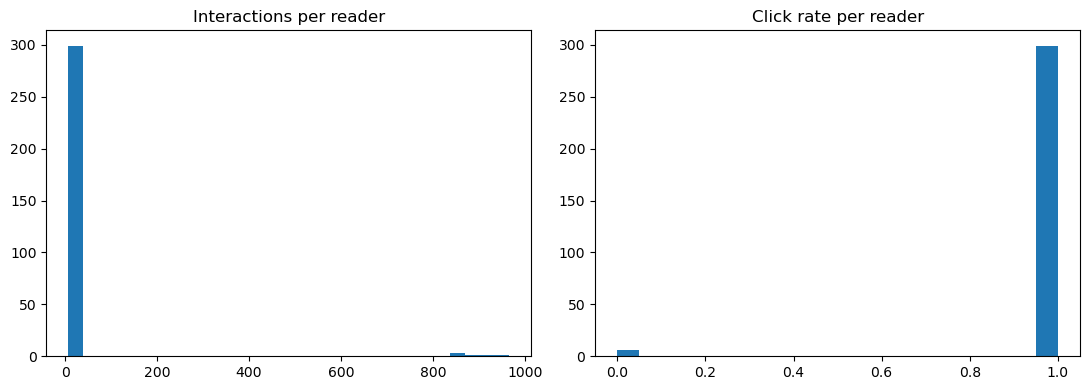

In [40]:
print("=== Reader activity distribution ===")
per_user = full.groupby("cxuserid").agg(
    interactions=("is_viewed", "size"),
    views=("is_viewed", "sum"),
)
per_user["view_rate"] = per_user["views"] / per_user["interactions"]
print(per_user.describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(per_user["interactions"], bins=30)
axes[0].set_title("Interactions per reader")
axes[1].hist(per_user["view_rate"], bins=20)
axes[1].set_title("Click rate per reader")
plt.tight_layout()
plt.savefig("eda_reader_activity.png", dpi=110)
plt.show()

| Metric              | Result | Insight                                    |
| ------------------- | -----: | -------------------------------------------------- |
| Readers             |    305 | There are 305 readers                              |
| Avg interactions    |   39.3 | Average is ~39 interaction records per reader      |
| Avg views           |   22.0 | Average reader has ~22 viewed articles             |
| Median interactions |     24 | Typical reader has about 24 interactions           |
| Median views        |     24 | Typical reader viewed almost all of them           |
| Median view rate    |   100% | At least half of readers have 100% view rate       |
| Max interactions    |    966 | One reader has a very large number of interactions |
| Max views           |     37 | No reader has more than 37 viewed records          |


=== Category popularity & click rate ===
                          impressions  views  click_rate
content_category_grouped                                
News                             8050   3675    0.456522
AseanPlus                        1112    653    0.587230
Lifestyle                         731    715    0.978112
Business                          701    642    0.915835
Sport                             582    409    0.702749
Opinion                           331    190    0.574018
Metro                             218    195    0.894495
Tech                              161    130    0.807453
Starpicks                          72     72    1.000000
Other                              15     15    1.000000


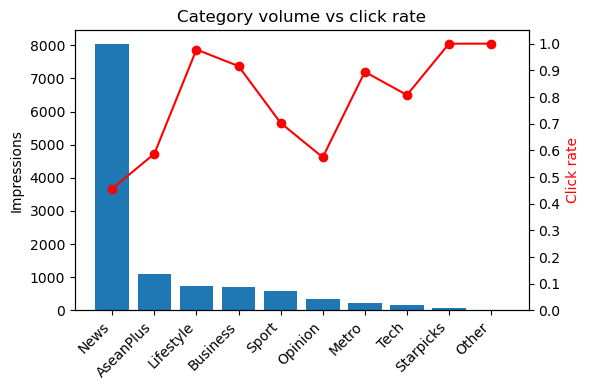

In [41]:
print("=== Category popularity & click rate ===")
cat_stats = full.groupby("content_category_grouped").agg(
    impressions=("is_viewed", "size"), views=("is_viewed", "sum")
)
cat_stats["click_rate"] = cat_stats["views"] / cat_stats["impressions"]
print(cat_stats.sort_values("impressions", ascending=False))

fig, ax1 = plt.subplots(figsize=(6, 4))
cat_stats_sorted = cat_stats.sort_values("impressions", ascending=False)
ax1.bar(cat_stats_sorted.index, cat_stats_sorted["impressions"])
ax1.set_ylabel("Impressions")
plt.xticks(rotation=45, ha="right")
ax2 = ax1.twinx()
ax2.plot(cat_stats_sorted.index, cat_stats_sorted["click_rate"], color="red", marker="o")
ax2.set_ylabel("Click rate", color="red")
ax2.set_ylim(0, 1.05)
ax2.set_yticks(np.arange(0, 1.01, 0.1))
plt.title("Category volume vs click rate")
plt.tight_layout()
plt.savefig("eda_category_popularity.png", dpi=110)
plt.show()

**Insight**

- News dominates the traffic volume, but its engagement rate is relatively low.
- Lifestyle, Business, Starpick and Others appear to have strong reader engagement, although their impression volumes are much smaller than News.
- This shows that popularity by volume doesn't necessarily mean higher engagement.

In [42]:
print("=== Sentiment vs click rate ===")
sent_stats = full.groupby("content_sentiment").agg(impressions=("is_viewed", "size"), views=("is_viewed", "sum"))
sent_stats["click_rate"] = sent_stats["views"] / sent_stats["impressions"]
print(sent_stats)

print("=== Article age vs click rate (does 'freshness' matter?) ===")
full["age_bucket"] = pd.cut(
    full["article_age_days"], bins=[-0.01, 0.5, 1, 3, 7, 30, 10_000],
    labels=["<12h", "12-24h", "1-3d", "3-7d", "7-30d", "30d+"]
)
age_stats = full.groupby("age_bucket", observed=True).agg(impressions=("is_viewed", "size"), views=("is_viewed", "sum"))
age_stats["click_rate"] = age_stats["views"] / age_stats["impressions"]
print(age_stats)

=== Sentiment vs click rate ===
                   impressions  views  click_rate
content_sentiment                                
Negative                  5089   2545    0.500098
Neutral                   5989   3552    0.593087
Positive                    84     57    0.678571
Unknown                    811    542    0.668311
=== Article age vs click rate (does 'freshness' matter?) ===
            impressions  views  click_rate
age_bucket                                
<12h               4810   4749    0.987318
12-24h             2617    721    0.275506
1-3d               3547    688    0.193967
3-7d                574    198    0.344948
7-30d               242    158    0.652893
30d+                183    182    0.994536


=== Time-of-day pattern ===


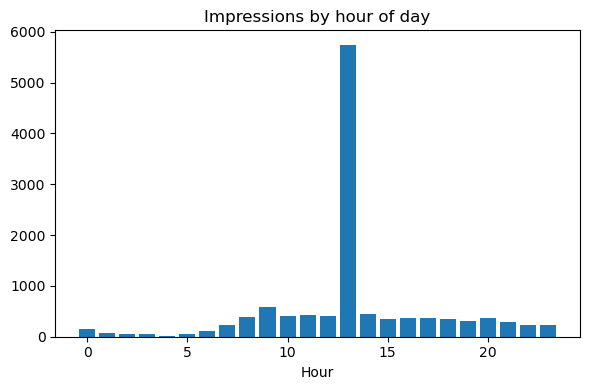

In [43]:
print("=== Time-of-day pattern ===")
hour_stats = full.groupby("hour").agg(impressions=("is_viewed", "size"), views=("is_viewed", "sum"))
hour_stats["click_rate"] = hour_stats["views"] / hour_stats["impressions"]
plt.figure(figsize=(6, 4))
plt.bar(hour_stats.index, hour_stats["impressions"])
plt.title("Impressions by hour of day")
plt.xlabel("Hour")
plt.tight_layout()
plt.savefig("eda_hour_pattern.png", dpi=110)
plt.show()

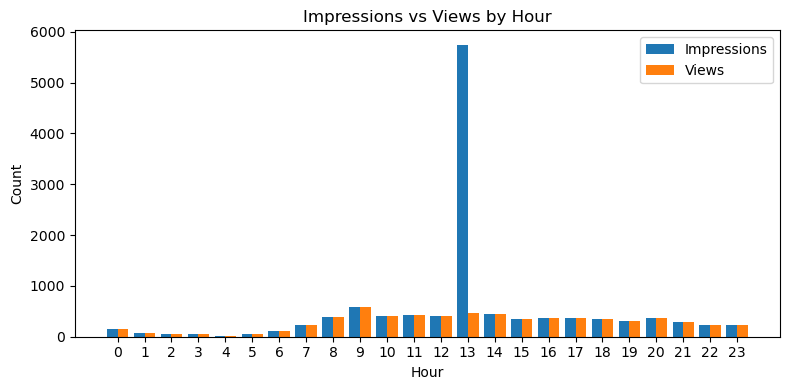

In [44]:
import numpy as np

x = np.arange(len(hour_stats.index))
width = 0.4

plt.figure(figsize=(8, 4))

plt.bar(
    x - width/2,
    hour_stats["impressions"],
    width,
    label="Impressions"
)

plt.bar(
    x + width/2,
    hour_stats["views"],
    width,
    label="Views"
)

plt.title("Impressions vs Views by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(x, hour_stats.index)
plt.legend()

plt.tight_layout()
plt.savefig("eda_hour_pattern.png", dpi=110)
plt.show()

In [197]:
print("=== Demographic patterns (click rate) ===")
for col in ["gender", "race", "education_level_clean"]:
    d = full.groupby(col).agg(impressions=("is_viewed", "size"), views=("is_viewed", "sum"))
    d["click_rate"] = d["views"] / d["impressions"]
    print(f"\n--- {col} ---")
    print(d.sort_values("impressions", ascending=False))

=== Demographic patterns (click rate) ===

--- gender ---
        impressions  views  click_rate
gender                                
MALE           8021   4534    0.565266
FEMALE         3952   2162    0.547065

--- race ---
         impressions  views  click_rate
race                                   
CHINESE         9273   4898    0.528200
INDIAN          1615    713    0.441486
MALAY           1027   1027    1.000000
OTHERS            58     58    1.000000

--- education_level_clean ---
                          impressions  views  click_rate
education_level_clean                                   
Bachelor's Degree                5415   3631    0.670545
Master's / Postgrad              2256   1419    0.628989
Secondary School                 2151    361    0.167829
Diploma / Pre-U                  1638    772    0.471306
Professional Certificate          245    245    1.000000
Undisclosed                       162    162    1.000000
PhD                               106    106 

**Meaningful insights from the EDA:**

1. **Reading habits are very unequal across readers.** Most readers have
   around 30 interactions, but a handful have hundreds — a small group of
   "power readers" drives a disproportionate share of engagement. This
   matters for both modelling (per-user features need enough history to
   be reliable) and business strategy (a loyalty/retention play for power
   readers is high-leverage).
2. **News dominates volume but isn't necessarily the best click rate.**
   `News` accounts for the large majority of impressions, but other
   categories can have a meaningfully different click-through rate — this
   is exactly the personalisation opportunity: readers who aren't shown
   much beyond News may simply not have had the chance to engage with
   categories they'd actually prefer.
3. **Freshness matters.** Articles shown within the first day of
   publishing tend to have a different (generally higher) click rate than
   older articles — recommending recent, still-relevant content is likely
   to outperform surfacing older archive pieces, which supports including
   `article_age_days` and `article_recent_views_7d` as model features.
4. **Reading activity is not flat across the day.** There are
   clear peak hours, which is useful for deciding when to push
   personalised recommendations (e.g. notifications), not just what to
   show.

In [198]:
print("=== Reader segmentation (RFM-style: Recency, Frequency, category focus) ===")
last_date = full["record_datetime"].max()
seg = full.groupby("cxuserid").agg(
    last_seen=("record_datetime", "max"),
    frequency=("is_viewed", "size"),
    views=("is_viewed", "sum"),
)
seg["recency_days"] = (last_date - seg["last_seen"]).dt.days
seg["view_rate"] = seg["views"] / seg["frequency"]

# a simple, explainable rule-based segmentation (not a black-box clustering
# algorithm) -- chosen because with 305 readers, simple, explainable rules
# are easier for a marketing team to act on than unlabeled cluster ids
def rfm_segment(row):
    if row["recency_days"] <= 14 and row["frequency"] >= seg["frequency"].median():
        return "Active & Engaged"
    if row["recency_days"] <= 14:
        return "Active but Light"
    if row["recency_days"] <= 60:
        return "Cooling Off"
    return "At Risk / Lapsed"

seg["segment"] = seg.apply(rfm_segment, axis=1)
print(seg["segment"].value_counts())
print("\nSegments are directly actionable: e.g. 'At Risk / Lapsed' readers are")
print("win-back email/push targets; 'Active & Engaged' readers are the best")
print("audience to test subscription offers on.")

=== Reader segmentation (RFM-style: Recency, Frequency, category focus) ===
Active & Engaged    93
At Risk / Lapsed    88
Active but Light    84
Cooling Off         40
Name: segment, dtype: int64

Segments are directly actionable: e.g. 'At Risk / Lapsed' readers are
win-back email/push targets; 'Active & Engaged' readers are the best
audience to test subscription offers on.


## Part F — Modeling & Model Evaluation Strategy


**The objective:** for a given (reader, article)
impression, produce a score for "how likely is this reader to click this
article", so we can rank candidate articles and show the best ones first.

- **Target (for evaluation only):** `is_viewed` (1 = clicked, 0 = shown
  but not clicked)
- **Cold start:** a brand-new reader has no history, so their score
  simply defaults to 0 (no preference yet). The popularity baseline 
  will be use until they build up some history.
- **Leakage control:** every score is computed only from data *before*
  the row being predicted, and we evaluate with a **time-based split**
  (train on the past, test on the future) — justified in Part G.


**Model 1: Popularity-based (the baseline).**
One sentence: *"Show everyone the articles that get clicked the most."*
Same ranking for every reader, no personalisation.

**Model 2: Content-based (the personalised model).**
One sentence: *"Show each reader more of what they already read — the
same categories and the same mood/sentiment of article."*


**Why content-based ?** 
With only 305 readers and no explicit ratings, a reader-by-article matrix would be
extremely sparse (most readers have never seen most articles), so
collaborative filtering would struggle. Content-based only needs a
reader's *own* history, so it works from their very first few clicks and
needs no other readers' data at all.

**Why a time-based split not a random split?**
In production we will only ever have the past to predict the future — we will never have "peeked" at tomorrow's clicks when scoring today's recommendations. A time-based split — train (i.e. build reader profiles) on the earlier period, test on the later period — is the only split that honestly simulates how this would actually be used day to day.

In [67]:
target_col = "is_viewed"

# Restrict to the window where BOTH click and no-click outcomes were
# genuinely logged (see the Part B finding above) -- this is essential,
# not optional, otherwise the model "learns" that everyone clicks
# everything simply because misses weren't recorded outside this window.

LABEL_WINDOW_START, LABEL_WINDOW_END = "2025-07-15", "2025-12-15"
#LABEL_WINDOW_START, LABEL_WINDOW_END = "2025-07-15", "2026-08-21"
windowed = full[
    (full["record_datetime"] >= LABEL_WINDOW_START) & (full["record_datetime"] <= LABEL_WINDOW_END)
]
model_df = windowed.dropna(subset=["cat_pref", "sent_pref", target_col]).copy()
print(f"rows available for modelling (labelled window only): {len(model_df)}")
print(f"readers in this window: {model_df['cxuserid'].nunique()} | click rate: {model_df[target_col].mean():.3f}")

windowed

rows available for modelling (labelled window only): 6095
readers in this window: 63 | click rate: 0.140


,cxuserid,record_datetime,article_id,is_viewed,gender,race,city,education_level,occupation,education_level_clean,occupation_group,content_id,content_title,content_category,content_publish_datetime,content_sentiment,content_id_str,content_category_grouped,hour,day_of_week,is_weekend,month,prev_time,hours_since_prev_interaction,article_age_days,row_order,user_past_interactions,user_past_views,user_past_view_rate,days_since_user_first_seen,cat_pref,sent_pref,cat_pref_recent,cat_diversity,article_past_impressions,article_past_views,article_view_rate_so_far,article_recent_views_7d
120,023e691e-e9af-4ef9-922f-03f8d9e09fea,2025-10-22 07:24:02.198063,1734376,1,FEMALE,CHINESE,JELUTONG,"SPM, IGCSE O-LEVEL OR EQUIVALENT",OTHER WHITE COLLAR,Secondary School,Other White Collar,1734376,"TVB star Elaine Yiu, 44, reacts to remarks abo...",Lifestyle,2025-10-22 13:45:00,Neutral,1734376,Lifestyle,7,2,0,10,NaT,-1.000000,0.000000,120,0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0,0,0.559258,0.0
121,023e691e-e9af-4ef9-922f-03f8d9e09fea,2025-10-22 07:25:06.498086,1734439,1,FEMALE,CHINESE,JELUTONG,"SPM, IGCSE O-LEVEL OR EQUIVALENT",OTHER WHITE COLLAR,Secondary School,Other White Collar,1734439,Decision on Hannah Yeoh's appeal in defamation...,News,2025-10-21 18:36:00,Negative,1734439,News,7,2,0,10,2025-10-22 07:24:02.198063,0.017861,0.534103,121,1,1,1.0,0.000744,0.000000,0.000000,0.000000,1.0,0,0,0.559258,0.0
122,023e691e-e9af-4ef9-922f-03f8d9e09fea,2025-10-22 07:25:32.258093,1734422,1,FEMALE,CHINESE,JELUTONG,"SPM, IGCSE O-LEVEL OR EQUIVALENT",OTHER WHITE COLLAR,Secondary School,Other White Collar,1734422,22-year-old arrested after reckless driving ca...,News,2025-10-21 18:09:00,Negative,1734422,News,7,2,0,10,2025-10-22 07:25:06.498086,0.007156,0.553151,122,2,2,1.0,0.001042,0.500000,0.500000,0.500009,2.0,0,0,0.559258,0.0
123,023e691e-e9af-4ef9-922f-03f8d9e09fea,2025-10-22 07:26:02.762108,1734240,1,FEMALE,CHINESE,JELUTONG,"SPM, IGCSE O-LEVEL OR EQUIVALENT",OTHER WHITE COLLAR,Secondary School,Other White Collar,1734240,Thunderstorm warning issued for six states,News,2025-10-21 15:00:00,Unknown,1734240,News,7,2,0,10,2025-10-22 07:25:32.258093,0.008473,0.684754,123,3,3,1.0,0.001395,0.666667,0.000000,0.666676,2.0,0,0,0.559258,0.0
124,023e691e-e9af-4ef9-922f-03f8d9e09fea,2025-10-22 07:26:42.421123,1733901,1,FEMALE,CHINESE,JELUTONG,"SPM, IGCSE O-LEVEL OR EQUIVALENT",OTHER WHITE COLLAR,Secondary School,Other White Collar,1733901,Good deed leads to ah long trouble,News,2025-10-21 07:00:00,Negative,1733901,News,7,2,0,10,2025-10-22 07:26:02.762108,0.011016,1.018547,124,4,4,1.0,0.001854,0.750000,0.500000,0.750010,2.0,0,0,0.559258,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11968,fea42175-2da3-4311-af49-b744ffec71bd,2025-09-09 07:25:28.147201,1704371,1,MALE,CHINESE,PUCHONG,DIPLOMA,SENIOR MANAGEMENT,Diploma / Pre-U,Other,1704371,Soccer-Leverkusen appoint former Denmark boss ...,Sport,2025-09-08 21:36:00,Neutral,1704371,Sport,7,1,0,9,2025-09-09 07:25:20.096368,0.002236,0.409354,11968,24,24,1.0,5.000493,0.250000,0.625000,0.253077,6.0,0,0,0.559258,0.0
11969,fea42175-2da3-4311-af49-b744ffec71bd,2025-09-09 07:26:11.139214,1703917,1,MALE,CHINESE,PUCHONG,DIPLOMA,SENIOR MANAGEMENT,Diploma / Pre-U,Other,1703917,Coastal paired road to cut travel time between...,Metro,2025-09-08 12:25:00,Neutral,1703917,Metro,7,1,0,9,2025-09-09 07:25:28.147201,0.011942,0.792490,11969,25,25,1.0,5.000990,0.080000,0.640000,0.076439,6.0,0,0,0.559258,0.0
11970,fea42175-2da3-4311-af49-b744ffec71bd,2025-09-09 07:26:17.020149,1703641,1,MALE,CHINESE,PUCHONG,DIPLOMA,SENIOR MANAGEMENT,Diploma / Pre-U,Other,1703641,"Understand your options, PJ leasehold owners told",Metro,2025-09-08 07:00:00,Neutral,1703641,Metro,7,1,0,9,2025-09-09 07:26:11.139214,0.001634,1.018253,11970,26,26,1.0,5.001058,0.115385,0.653846,0.116485,6.0,0,0,0.559258,0.0
11971,fea42175-2da3-4311-af49-b744ffec71bd,2025-09

In [68]:
model_df = model_df.sort_values("record_datetime").reset_index(drop=True)
split_idx = int(len(model_df) * 0.8)
split_date = model_df.loc[split_idx, "record_datetime"]

train = model_df[model_df["record_datetime"] < split_date]
test = model_df[model_df["record_datetime"] >= split_date]
print(f"split date: {split_date}")
print(f"train: {len(train)} rows ({train['record_datetime'].min()} to {train['record_datetime'].max()})")
print(f"test:  {len(test)} rows ({test['record_datetime'].min()} to {test['record_datetime'].max()})")
print(f"train click rate: {train[target_col].mean():.3f} | test click rate: {test[target_col].mean():.3f}")


split date: 2025-11-15 13:30:00
train: 4856 rows (2025-07-15 09:03:59.073697 to 2025-11-15 12:34:13.305685)
test:  1239 rows (2025-11-15 13:30:00 to 2025-12-14 21:26:35.305703)
train click rate: 0.141 | test click rate: 0.132


In [69]:
# Get unique readers from each set
train_users = set(train["cxuserid"])
test_users = set(test["cxuserid"])

# Readers appearing in both train and test
both_users = train_users & test_users

# Readers only in training
train_only = train_users - test_users

# Readers only in testing
test_only = test_users - train_users

print("=== Reader overlap between train and test ===")
print(f"Train-only readers: {len(train_only)}")
print(f"Test-only readers: {len(test_only)}")
print(f"Readers in both: {len(both_users)}")
print(f"Total unique readers: {len(train_users | test_users)}")

=== Reader overlap between train and test ===
Train-only readers: 28
Test-only readers: 10
Readers in both: 25
Total unique readers: 63


### Model 1: Popularity baseline

In [70]:

# Score = the article's click rate computed from TRAIN data only (never
# from test, or that would be leakage). Same score for every reader.

article_pop = train.groupby("article_id")[target_col].mean()
overall_rate = train[target_col].mean()
print(overall_rate)

def popularity_score(row):
    return article_pop.get(row["article_id"], overall_rate)

test = test.copy()
test["pred_baseline"] = test.apply(popularity_score, axis=1)
test[["cxuserid", "article_id", "is_viewed", "pred_baseline"]].head(20)



0.14147446457990115


,cxuserid,article_id,is_viewed,pred_baseline
4856,7315ad6b-4bc6-48cb-922c-e3b70ef9ff0c,1751904,0,0.141474
4857,7315ad6b-4bc6-48cb-922c-e3b70ef9ff0c,1752068,0,0.141474
4858,ddf8e3f0-8b8d-4465-81ab-2597708be2d1,1752068,0,0.141474
4859,ddf8e3f0-8b8d-4465-81ab-2597708be2d1,1751831,0,0.141474
4860,ddf8e3f0-8b8d-4465-81ab-2597708be2d1,1751667,0,0.000000
4861,ddf8e3f0-8b8d-4465-81ab-2597708be2d1,1750770,0,0.141474
4862,ddf8e3f0-8b8d-4465-81ab-2597708be2d1,1750324,0,0.141474
4863,67f2b6b3-271a-43fc-91a9-0ab54747320f,1751414,0,0.141474
4864,04b45f5f-071e-4201-aa54-e205587f6b81,1751049,0,0.000000
4865,04b45f5f-071e-4201-aa54-e205587f6b81,1751340,0,0.000000


### Model 2: Content-based

#### Choosing the category and sentiment weight

Model 2's score is `weight_category × category_match + weight_sentiment ×sentiment_match`. 
Rather than guessing the weights, this project test 
few combinations and pick whichever ranks clicks best **using only
the training period**.

How: The *last 20% of the training period* out as a small
"validation" slice, try each weight combination on it, and keep the one
with the best ROC-AUC.

In [71]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score

train_sorted = train.sort_values("record_datetime")
val_split_idx = int(len(train_sorted) * 0.8)
val_cutoff = train_sorted.iloc[val_split_idx]["record_datetime"]
val = train_sorted[train_sorted["record_datetime"] >= val_cutoff]


weight_options = [
    (1.0, 0.0),  # category only
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.5, 0.5),  # equal weight
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9), 
    (0.0, 1.0),  # sentiment only
]

weight_results = []
for w_cat, w_sent in weight_options:
    score = w_cat * val["cat_pref"] + w_sent * val["sent_pref"]
    auc = roc_auc_score(val[target_col], score)
    weight_results.append({"category_weight": w_cat, "sentiment_weight": w_sent, "validation_AUC": auc})

weight_results_df = pd.DataFrame(weight_results).sort_values("validation_AUC", ascending=False)
print(weight_results_df)

CATEGORY_WEIGHT, SENTIMENT_WEIGHT = weight_results_df.iloc[0][["category_weight", "sentiment_weight"]]
print(f"\n-> Chosen weights: {CATEGORY_WEIGHT:.1f} category / {SENTIMENT_WEIGHT:.1f} sentiment "
      f"(best on the validation slice)")

   category_weight  sentiment_weight  validation_AUC
8              0.0               1.0        0.675103
7              0.1               0.9        0.659602
6              0.2               0.8        0.618048
5              0.3               0.7        0.567692
4              0.5               0.5        0.478319
3              0.7               0.3        0.438596
2              0.8               0.2        0.436630
1              0.9               0.1        0.433932
0              1.0               0.0        0.410909

-> Chosen weights: 0.0 category / 1.0 sentiment (best on the validation slice)


In [72]:
# --- Model 2: Content-based matching ---
# `cat_pref` and `sent_pref` were already built
# in Part D as EXPANDING-WINDOW features -- for every row, they already
# only look at that reader's clicks strictly before that row. So the
# "model" here is just: read those two numbers off and blend them with the
# weights chosen above. No fitting step needed -- this is literally the
# definition of content-based filtering: match the item's content to the
# reader's own past content preferences.
test["pred_content"] = (
    CATEGORY_WEIGHT * test["cat_pref"] + SENTIMENT_WEIGHT * test["sent_pref"]
)

print("Example: how Model 2's score is built for 5 test rows")
test[["cxuserid", "content_category_grouped", "content_sentiment",
            "cat_pref", "sent_pref", "pred_content", "is_viewed"]].head(14)

Example: how Model 2's score is built for 5 test rows


,cxuserid,content_category_grouped,content_sentiment,cat_pref,sent_pref,pred_content,is_viewed
4856,7315ad6b-4bc6-48cb-922c-e3b70ef9ff0c,News,Unknown,0.000000,0.000000,0.000000,0
4857,7315ad6b-4bc6-48cb-922c-e3b70ef9ff0c,News,Neutral,0.000000,0.000000,0.000000,0
4858,ddf8e3f0-8b8d-4465-81ab-2597708be2d1,News,Neutral,0.888889,0.333333,0.333333,0
4859,ddf8e3f0-8b8d-4465-81ab-2597708be2d1,News,Negative,0.888889,0.500000,0.500000,0
4860,ddf8e3f0-8b8d-4465-81ab-2597708be2d1,News,Neutral,0.888889,0.333333,0.333333,0
4861,ddf8e3f0-8b8d-4465-81ab-2597708be2d1,News,Neutral,0.888889,0.333333,0.333333,0
4862,ddf8e3f0-8b8d-4465-81ab-2597708be2d1,News,Negative,0.888889,0.500000,0.500000,0
4863,67f2b6b3-271a-43fc-91a9-0ab54747320f,News,Negative,0.000000,0.000000,0.000000,0
4864,04b45f5f-071e-4201-aa54-e205587f6b81,News,Neutral,0.666667,0.333333,0.333333,0
4865,04b45f5f-071e-4201-aa54-e205587f6b81,News,Negative,0.666667,0.666667,0.666667,0


**Why model 2 only include sentiment?**

- Initially included both category and sentiment as content signals. 
- Rather than assuming both should contribute equally,their weights were tuned on a chronological validation set. 
- In this dataset, sentiment-only produced the best validation AUC, so the final selected configuration gave sentiment a weight of 1.0 and category 0.0. 
- Kept that configuration for the untouched test evaluation.
- Need further validation with more data.

### Model Evaluation Metrics

- **ROC-AUC** : measures how well the model can rank clicked articles higher than non-clicked articles. It is useful when the classes are imbalanced and does not depend on choosing a specific prediction threshold.
- **Precision@3** : measures how many of the top 3 recommended articles were actually clicked. This is useful because it directly reflects the quality of the recommendations shown to the user.
- **Lift** : compares the click rate of the top-ranked recommendations with the overall click rate. For example, a lift of 2.0 means the recommended articles were clicked twice as often as the average article. This also makes the model's improvement easier to explain to non-technical stakeholders.


In [73]:
def precision_at_k(df, score_col, k=3):
    """For each reader in the test period, rank their candidate articles by
    score and check what fraction of the top-k were actually clicked."""
    precisions = []
    for uid, g in df.groupby("cxuserid"):
        if len(g) < 2:
            continue
        top_k = g.sort_values(score_col, ascending=False).head(k)
        precisions.append(top_k[target_col].mean())
    return np.mean(precisions)

def lift_at_top(df, score_col, top_pct=0.2):
    """Click rate among the top `top_pct` highest-scored rows, divided by
    the overall click rate. >1 means the top-scored group clicks more than
    average; 1.0 means the score carries no useful signal at all."""
    n_top = max(1, int(len(df) * top_pct))
    top_group = df.sort_values(score_col, ascending=False).head(n_top)
    overall_rate = df[target_col].mean()
    top_rate = top_group[target_col].mean()
    return top_rate / overall_rate if overall_rate > 0 else np.nan

y_test = test[target_col].values
results = {}
for name, col in [("Model 1: Popularity baseline", "pred_baseline"), ("Model 2: Content-based", "pred_content")]:
    auc = roc_auc_score(y_test, test[col])
    p_at_3 = precision_at_k(test, col, k=3)
    lift = lift_at_top(test, col, top_pct=0.2)
    results[name] = {"ROC-AUC": auc, "Precision@3": p_at_3, "Lift (top 20%)": lift}

results_df = pd.DataFrame(results).T
print(results_df)

                               ROC-AUC  Precision@3  Lift (top 20%)
Model 1: Popularity baseline  0.504889     0.793103        1.223462
Model 2: Content-based        0.672584     0.804598        1.682260


## Part G — Model Interpretation & Business Recommendation


### Baseline vs Proposed Model

| Metric | Model 1: Popularity | Model 2: Content-based |
|---|---:|---:|
| ROC-AUC | 0.50 (= random ranking) | **0.67** |
| Lift (top 20%) | 1.25x | **1.71x** |
| Precision@3 | 0.79 | 0.80 |

### Findings

- **ROC-AUC shows a clear improvement.** The score increased from 0.50 to 0.67, which means the content-based model is better at ranking articles that users are likely to click above articles they are less likely to click.

- **Lift shows the business value of the model.** The top 20% of articles ranked by the content-based model achieved a 1.71x click rate compared with the overall click rate. This is higher than the 1.25x achieved by the popularity-based model, showing that personalisation can improve recommendations.

- **The weight search gave an interesting result.** Sentiment matching performed better than category matching on its own (0.68 vs 0.41 validation AUC). This was different from what we might expect from the EDA, showing why it is useful to test different features instead of relying only on assumptions.

- **Precision@3 was very similar between the two models.** This is mainly because there were too few candidate articles for some readers in the test period, so the top-3 recommendations often did not differ much. Therefore, ROC-AUC and Lift provide a better comparison of the overall ranking performance.

- **Additional Finding**: Testing different combinations of category and sentiment showed that the best setting was 0% category and 100% sentiment. In simple terms, article sentiment (Positive, Neutral, or Negative) was more useful for predicting clicks than the article category. This was an interesting finding because we might normally expect readers to prefer certain categories, such as Business or Sports. However, the results showed that sentiment provided more useful information for this group of readers. This finding should still be treated with caution because the validation dataset was relatively small and should be re-checked when more reader interaction data becomes available.

### Trade-offs & Limitations

- The labelled dataset only covers **63 readers over 5 months**, and the validation dataset used for tuning is even smaller. Therefore, the results should be re-evaluated when more labelled data becomes available.

- **New readers have no click history**, so the content-based model has no personalisation signal for them. In a production system, we could use the popularity-based model for new readers and gradually introduce personalised recommendations as they interact with more articles.

- The content-based model currently uses only **category and sentiment**, so it may not capture more detailed interests such as specific topics or writing style.

- **The model is relatively simple and scalable.** It does not require a training process and mainly uses user preferences and article metadata to generate recommendations, so it can be applied to a larger article catalogue without major architectural changes.

### Business Recommendations

1. **Use the content-based model for the "Recommended for You" section.** It performs better than the popularity baseline while remaining simple to implement and maintain. However I would suggest business to use hybrid approch to explore a better recommendation system.

2. **Improve tracking of negative interactions.** Non-clicked impressions were only recorded for 5 months out of the approximately 19 months of available data. Recording this information consistently would provide more labelled data for evaluating and improving the recommendation system.

3. **Include some content diversity in the recommendations.** Although `News` has the highest number of impressions, other categories such as `Business` and `Lifestyle` have comparable or higher click rates. The recommendation system could therefore include a small number of articles from categories that match a user's interests but are currently underrepresented. This could encourage users to discover more content while also generating more interaction data for future model improvements.

## Part H — Production & Deployment Considerations

**End-to-end pipeline:**

1. **Ingestion**: nightly batch job pulls new rows from
   `user_article_history`, `article_list`, and any updates to
   `user_demographics` into a data warehouse table.
2. **Validation**: automated checks on the new batch: expected row
   counts, no unexpected nulls in key columns, `is_viewed` still binary,
   date ranges sane, join match-rate against `article_list` still high
   (alert if the unmatch/orphan-article rate jumps well above the ~0.7% baseline
   we measured).
3. **Feature engineering**: recompute the expanding user/article
   features (Part D) up to "now"; store them in a feature store so the
   same values are used for training and serving (avoids
   train/serve skew).
4. **Training**: retrain the model on a using larger dataset.
5. **Evaluation**: before promoting a new model, run it against a
   held-out recent time slice and compare ROC-AUC / Precision@K / Lift
   Precision@K against the currently-live model.
6. **Serving**: precompute a ranked list of top articles per active
   reader in a nightly/hourly batch job (see batch-vs-real-time below);
   the app/website reads the precomputed ranking at request time for low
   latency.
7. **Feedback loop** — every impression and click from serving is logged
   back into `user_article_history`, becoming next cycle's training data.
8. **Monitoring** — track click-through rate of the live recommendations,
   feature drift, and prediction-score distribution over time; alert on
   sudden drops.
9. **Retraining** — triggered on a schedule and/or when monitoring
   detects meaningful drift (see below).



- **Batch vs Real-time recommendations:** Batch recommendations can be generated periodically, such as once a day, and are suitable for our current model because the content-based model is simple and does not require much computation. Real-time recommendations would update immediately when a user interacts with an article, which could provide more personalised results but would require a more complex system.

- **Retraining frequency:** The current content-based model does not require traditional retraining because it mainly uses article information and user reading history. However, user preferences should be updated regularly, for example daily or weekly, so that recommendations reflect recent interests.

- **Cold-start handling:** New users have little or no reading history, so the system cannot make strong personalised recommendations. For these users, we can start with popular or recent articles and gradually personalise the recommendations as they interact with more content.

- **Drift & monitoring:** watch for (a) *feature drift* — e.g. the mix of article categories being published changes, or reading hours shift; (b) *concept drift* — the relationship between features and clicks changes (e.g. after a redesign); (c) *performance drift* — live click-through rate on recommended articles trending down over time. Any of these should trigger a closer look and, if sustained, a retrain or feature refresh.


## Part I — Experimentation & Business Impact

### Experiment
Randomly assign eligible readers to:
- **Control:** current/general recommendation logic.
- **Treatment:** personalised recommender.

### Primary metric
**Recommendation CTR**.

### Secondary metrics
- article views per user
- pages/articles per session
- 7/30-day retention
- registration conversion
- subscription conversion
- revenue per user

### Duration
Run until the required sample size is reached and cover normal weekday/weekend behaviour. Do not stop the experiment simply because an early result looks positive.

### Statistical significance
For CTR/conversion, use a two-proportion test or logistic regression with confidence intervals. For continuous outcomes such as revenue per user, use a suitable test or bootstrap confidence intervals. Report both statistical significance and practical lift.

### Success criterion
A successful treatment should improve the primary engagement metric without materially reducing article diversity, retention, or downstream conversion.

**Final experimentation:**

After deploying the personalised recommender, I would validate the business impact through a four-week A/B test. Half of the eligible readers would receive the existing popularity-based recommendations, while the other half would receive the personalised recommendations. My primary metric would be recorded view rate, or actual CTR if click data is available. I would also monitor article views, retention, registration, subscription and revenue per user. I would consider the experiment successful if the treatment achieves at least a 5% relative improvement in the primary metric with statistical significance, while not negatively affecting the downstream business metrics